# FAQ Chatbot — Fine-tuning `distilbert-base-multilingual-cased`

**Abordagem:** classificação de intenções (intent classification).  
O modelo aprende a mapear uma pergunta do usuário para uma **classe/intenção** (cada FAQ é uma classe).  
Na inferência, dado o índice previsto, o chatbot retorna a resposta correspondente.

```
Pergunta do usuário → DistilBERT → logits → argmax → intent_id → resposta fixa
```

> **Modelo base:** `distilbert-base-multilingual-cased`  
> Suporta 104 idiomas, incluindo Português, Inglês, Espanhol, etc.

## 0. Instalações

In [13]:
!pip install transformers datasets torch scikit-learn pandas numpy accelerate -q

## 1. Estrutura e preparação do dataset

### Formato esperado: `faq_dataset.json`

Cada entrada representa uma **intenção** (intent). O campo `questions` contém **variações** da mesma pergunta — quanto mais variações, melhor a generalização.

```json
[
  {
    "intent": "horario_funcionamento",
    "answer": "Funcionamos de segunda a sexta, das 8h às 18h.",
    "questions": [
      "Qual é o horário de funcionamento?",
      "Que horas vocês abrem?",
      "Vocês funcionam aos sábados?",
      "Qual o horário de atendimento?",
      "A empresa abre no fim de semana?"
    ]
  },
  {
    "intent": "formas_pagamento",
    "answer": "Aceitamos cartão de crédito, débito, Pix e boleto bancário.",
    "questions": [
      "Quais formas de pagamento vocês aceitam?",
      "Posso pagar com Pix?",
      "Vocês aceitam cartão?",
      "Como posso pagar?",
      "Aceita boleto?"
    ]
  }
]
```

**Dicas para preparação:**
- Mínimo recomendado: **5–10 variações por intenção**
- Use sinônimos, reordenações e formulações diferentes
- Inclua erros de digitação comuns se quiser robustez
- Mínimo de **2 intenções** para classificação funcionar
- Salve o arquivo como `faq_dataset.json` no mesmo diretório do notebook

## 2. Imports e configurações gerais

In [14]:
import json
import os
import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# ── Reprodutibilidade ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Configurações gerais ───────────────────────────────────────────────────────
MODEL_NAME    = "distilbert-base-multilingual-cased"
DATASET_PATH  = "faq_dataset_bigger.json"   # << coloque o caminho do seu JSON aqui
MAX_LEN       = 64     # comprimento máximo de tokens (64–128 é suficiente para FAQs)
BATCH_SIZE    = 16
EPOCHS        = 100
LEARNING_RATE = 2e-5
TEST_SIZE     = 0.15   # 15% para validação
SAVE_DIR      = "./faq_model"        # diretório onde o modelo treinado será salvo

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")

Dispositivo: cuda


## 3. Carregamento e preparação do dataset

In [15]:
# ── Carrega o JSON ─────────────────────────────────────────────────────────────
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

# ── Mapeamento intent <-> índice numérico ──────────────────────────────────────
intents      = [entry["intent"] for entry in raw_data]
intent2idx   = {intent: idx for idx, intent in enumerate(intents)}
idx2intent   = {idx: intent for intent, idx in intent2idx.items()}
intent2answer = {entry["intent"]: entry["answer"] for entry in raw_data}
num_labels   = len(intents)

print(f"Intenções encontradas ({num_labels}): {intents}")

# ── Expande para pares (pergunta, label) ───────────────────────────────────────
texts, labels = [], []
for entry in raw_data:
    for question in entry["questions"]:
        texts.append(question)
        labels.append(intent2idx[entry["intent"]])

print(f"Total de exemplos: {len(texts)}")

# ── Split treino / validação ───────────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    texts, labels,
    test_size=TEST_SIZE,
    stratify=labels,   # mantém proporção de classes
    random_state=SEED
)

print(f"Treino: {len(X_train)} | Validação: {len(X_val)}")

Intenções encontradas (52): ['estao_cobrando_um_seguro_em_meu_cartao_de_credito_que_eu_nao', 'estao_descontando_um_emprestimo_ja_quitado_na_minha_folha_de', 'estao_descontando_do_meu_beneficio_um_valor_referente_a_um_e', 'nao_querem_entregar_meu_contrato', 'tenho_um_plano_de_telefone_e_quero_cancelar_e_nao_estou_cons', 'estao_cobrando_no_meu_beneficio_um_valor_referente_a_rmc_e_r', 'comprei_um_produto_atraves_de_determinada_loja_de_uma_plataf', 'fiz_uma_reclamacao_atraves_do_procon_online_mas_nao_consegui', 'fui_cancelar_o_contrato_e_foi_cobrado_uma_multa_pode', 'um_contrato_pode_ter_fidelidade', 'arrependimento_de_7_dias', 'vale_para_compra_em_loja_fisica', 'quem_paga_o_frete_de_devolucao', 'abri_a_embalagem_e_usei_o_produto_ainda_posso_devolver', 'o_prazo_de_entrega_nao_foi_respeitado_e_agora', 'o_que_e_vicio_aparente', 'o_que_e_vicio_oculto', 'como_contar_o_prazo_no_vicio_oculto', 'prazos_para_reclamacao', 'vicio_ou_defeito', 'apos_receber_um_produto_novo_atraves_da_garantia_como_fi

## 4. Tokenizador e Dataset PyTorch

In [16]:
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

class FAQDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding="max_length",
            max_length=max_len,
            return_tensors="pt",
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx],
        }

train_dataset = FAQDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = FAQDataset(X_val,   y_val,   tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print("Datasets e DataLoaders prontos.")

Datasets e DataLoaders prontos.


## 5. Modelo, otimizador e scheduler

In [17]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
)
model.to(DEVICE)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(0.1 * total_steps)   # 10% de warmup
scheduler     = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Parâmetros treináveis: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Steps totais: {total_steps} | Warmup: {warmup_steps}")

Loading weights: 100%|██████████| 100/100 [00:01<00:00, 96.76it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parâmetros treináveis: 135,364,660
Steps totais: 10800 | Warmup: 1080


## 6. Loop de treinamento

In [18]:
def evaluate(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels_batch   = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels_batch,
            )
            total_loss += outputs.loss.item()
            preds = outputs.logits.argmax(dim=-1)
            correct += (preds == labels_batch).sum().item()
            total   += labels_batch.size(0)

    return total_loss / len(loader), correct / total


best_val_acc = 0.0
history = []

for epoch in range(1, EPOCHS + 1):
    # ── Treino ─────────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0

    for batch in train_loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels_batch   = batch["labels"].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels_batch,
        )
        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        train_loss += outputs.loss.item()

    train_loss /= len(train_loader)

    # ── Validação ──────────────────────────────────────────────────────────────
    val_loss, val_acc = evaluate(model, val_loader, DEVICE)
    history.append({"epoch": epoch, "train_loss": train_loss,
                    "val_loss": val_loss, "val_acc": val_acc})

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f}")

    # ── Salva melhor modelo (early-save) ───────────────────────────────────────
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)
        print(f"   ↳ Melhor modelo salvo (val_acc={val_acc:.4f})")

print(f"\nTreinamento concluído. Melhor val_acc: {best_val_acc:.4f}")

Epoch 01/100 | Train Loss: 3.9580 | Val Loss: 3.9469 | Val Acc: 0.0197


Writing model shards: 100%|██████████| 1/1 [00:05<00:00,  5.88s/it]


   ↳ Melhor modelo salvo (val_acc=0.0197)
Epoch 02/100 | Train Loss: 3.9230 | Val Loss: 3.8536 | Val Acc: 0.1316


Writing model shards: 100%|██████████| 1/1 [00:05<00:00,  5.37s/it]


   ↳ Melhor modelo salvo (val_acc=0.1316)
Epoch 03/100 | Train Loss: 3.6760 | Val Loss: 3.3245 | Val Acc: 0.6974


...

   ↳ Melhor modelo salvo (val_acc=0.8717)
Epoch 05/100 | Train Loss: 2.3858 | Val Loss: 1.8386 | Val Acc: 0.8914


Writing model shards: 100%|██████████| 1/1 [00:05<00:00,  5.32s/it]


   ↳ Melhor modelo salvo (val_acc=0.8914)
Epoch 06/100 | Train Loss: 1.7206 | Val Loss: 1.2238 | Val Acc: 0.9243


Writing model shards: 100%|██████████| 1/1 [00:05<00:00,  5.84s/it]


   ↳ Melhor modelo salvo (val_acc=0.9243)
Epoch 07/100 | Train Loss: 1.1373 | Val Loss: 0.7740 | Val Acc: 0.9112
Epoch 08/100 | Train Loss: 0.7191 | Val Loss: 0.5086 | Val Acc: 0.9112
Epoch 09/100 | Train Loss: 0.4758 | Val Loss: 0.3731 | Val Acc: 0.9211
Epoch 10/100 | Train Loss: 0.3576 | Val Loss: 0.3195 | Val Acc: 0.9112
Epoch 11/100 | Train Loss: 0.3060 | Val Loss: 0.3046 | Val Acc: 0.9112
Epoch 12/100 | Train Loss: 0.2759 | Val Loss: 0.2811 | Val Acc: 0.9178
Epoch 13/100 | Train Loss: 0.2606 | Val Loss: 0.2838 | Val Acc: 0.9112
Epoch 14/100 | Train Loss: 0.2476 | Val Loss: 0.2789 | Val Acc: 0.9112
Epoch 15/100 | Train Loss: 0.2386 | Val Loss: 0.2757 | Val Acc: 0.9112
Epoch 16/100 | Train Loss: 0.2344 | Val Loss: 0.2886 | Val Acc: 0.9112
Epoch 17/100 | Train Loss: 0.2332 | Val Loss: 0.2775 | Val Acc: 0.9112
Epoch 18/100 | Train Loss: 0.2311 | Val Loss: 0.2748 | Val Acc: 0.9243
Epoch 19/100 | Train Loss: 0.2294 | Val Loss: 0.2744 | Val Acc: 0.9243
Epoch 20/100 | Train Loss: 0.2246 |

## 7. Relatório de classificação detalhado

In [19]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in val_loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels_batch   = batch["labels"]

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = outputs.logits.argmax(dim=-1).cpu()

        all_preds.extend(preds.tolist())
        all_labels.extend(labels_batch.tolist())

target_names = [idx2intent[i] for i in range(num_labels)]
print(classification_report(all_labels, all_preds, target_names=target_names))

                                                              precision    recall  f1-score   support

estao_cobrando_um_seguro_em_meu_cartao_de_credito_que_eu_nao       1.00      1.00      1.00         8
estao_descontando_um_emprestimo_ja_quitado_na_minha_folha_de       1.00      1.00      1.00         5
estao_descontando_do_meu_beneficio_um_valor_referente_a_um_e       0.17      0.25      0.20         4
                            nao_querem_entregar_meu_contrato       1.00      1.00      1.00         6
tenho_um_plano_de_telefone_e_quero_cancelar_e_nao_estou_cons       1.00      1.00      1.00         6
estao_cobrando_no_meu_beneficio_um_valor_referente_a_rmc_e_r       0.25      0.17      0.20         6
comprei_um_produto_atraves_de_determinada_loja_de_uma_plataf       1.00      1.00      1.00         5
fiz_uma_reclamacao_atraves_do_procon_online_mas_nao_consegui       1.00      0.80      0.89         5
        fui_cancelar_o_contrato_e_foi_cobrado_uma_multa_pode       1.00      0.57

## 8. Curva de treinamento

In [20]:
!pip install matplotlib

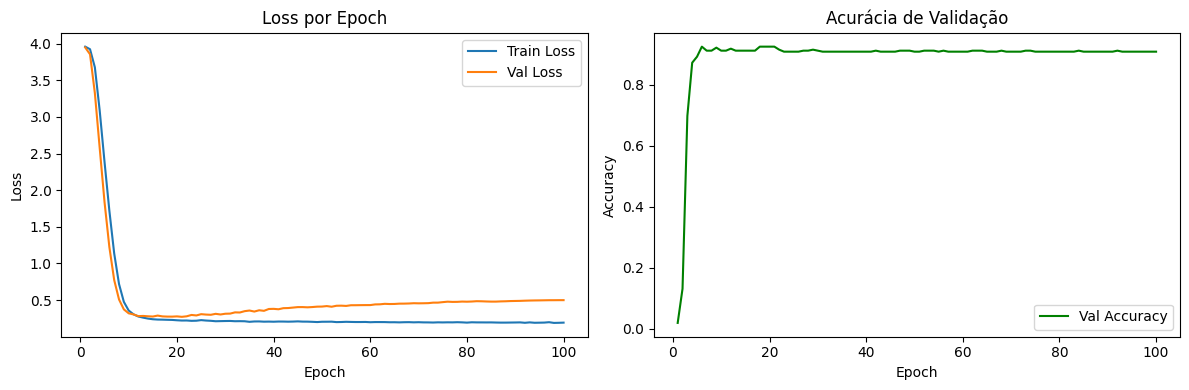

In [21]:
import matplotlib.pyplot as plt

df_history = pd.DataFrame(history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(df_history["epoch"], df_history["train_loss"], label="Train Loss")
ax1.plot(df_history["epoch"], df_history["val_loss"],   label="Val Loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Loss por Epoch"); ax1.legend()

ax2.plot(df_history["epoch"], df_history["val_acc"], color="green", label="Val Accuracy")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_title("Acurácia de Validação"); ax2.legend()

plt.tight_layout()
plt.savefig("training_curve.png", dpi=120)
plt.show()

## 9. Inferência — chatbot interativo

Carrega o **melhor modelo salvo** e responde perguntas em tempo real.

In [ ]:
import torch.nn.functional as F

# ── Carrega modelo salvo ───────────────────────────────────────────────────────
infer_tokenizer = DistilBertTokenizerFast.from_pretrained(SAVE_DIR)
infer_model     = DistilBertForSequenceClassification.from_pretrained(SAVE_DIR)
infer_model.to(DEVICE)
infer_model.eval()

CONFIDENCE_THRESHOLD = 0.70   # abaixo disso → "não sei responder"

def predict(question: str):
    """Retorna (intent, resposta, confiança)."""
    encoding = infer_tokenizer(
        question,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    )
    input_ids      = encoding["input_ids"].to(DEVICE)
    attention_mask = encoding["attention_mask"].to(DEVICE)

    with torch.no_grad():
        logits = infer_model(input_ids=input_ids, attention_mask=attention_mask).logits

    probs      = F.softmax(logits, dim=-1).squeeze()
    confidence = probs.max().item()
    intent_idx = probs.argmax().item()
    intent     = idx2intent[intent_idx]
    answer     = intent2answer[intent]
    return intent, answer, confidence


def chat(question: str):
    intent, answer, confidence = predict(question)
    if confidence < CONFIDENCE_THRESHOLD:
        return ("⚠️  Desculpe, não encontrei uma resposta para isso. "
                "Tente reformular sua pergunta.")
    return f"{answer}  [intent={intent}, confiança={confidence:.2%}]"


# ── Teste rápido ───────────────────────────────────────────────────────────────
test_questions = [
    "Que horas vocês abrem?",
    "Aceita cartão de crédito?",
    "Quero falar com um atendente",   # pergunta fora do domínio (deve ativar threshold)
]

for q in test_questions:
    print(f"Q: {q}")
    print(f"A: {chat(q)}\n")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3811.97it/s]

Q: Que horas vocês abrem?
A: ⚠️  Desculpe, não encontrei uma resposta para isso. Tente reformular sua pergunta.

Q: Aceita cartão de crédito?
A: ⚠️  Desculpe, não encontrei uma resposta para isso. Tente reformular sua pergunta.

Q: Quero falar com um atendente
A: ⚠️  Desculpe, não encontrei uma resposta para isso. Tente reformular sua pergunta.



## 10. Loop interativo (terminal / Colab)

In [23]:
print("FAQ Chatbot pronto! Digite 'sair' para encerrar.\n")
while True:
    user_input = input("Você: ").strip()
    if not user_input or user_input.lower() in {"sair", "exit", "quit"}:
        print("Chatbot: Até logo!")
        break
    print(f"Chatbot: {chat(user_input)}\n")

FAQ Chatbot pronto! Digite 'sair' para encerrar.

Chatbot: ⚠️  Desculpe, não encontrei uma resposta para isso. Tente reformular sua pergunta.

Chatbot: ⚠️  Desculpe, não encontrei uma resposta para isso. Tente reformular sua pergunta.

Chatbot: ⚠️  Desculpe, não encontrei uma resposta para isso. Tente reformular sua pergunta.

Chatbot: Até logo!


## 11. Artefatos salvos

Após o treinamento, o diretório `./faq_model/` conterá:

| Arquivo | Descrição |
|---|---|
| `config.json` | Configuração do modelo (num_labels, etc.) |
| `pytorch_model.bin` | Pesos treinados |
| `tokenizer_config.json` | Configuração do tokenizador |
| `vocab.txt` | Vocabulário multilingual |

Para reutilizar em produção, basta carregar `SAVE_DIR` com `from_pretrained()` (seção 9).

---

### Dicas para melhorar o desempenho

- **Mais variações por intent:** 10–20 é o ideal para datasets pequenos  
- **Data augmentation:** inverta a ordem das palavras, use sinônimos  
- **Ajuste `CONFIDENCE_THRESHOLD`:** suba para 0.70 em produção para respostas mais seguras  
- **Overfitting?** Reduza `EPOCHS` ou aumente `TEST_SIZE`; monitore val_loss  
- **Muitos intents (>50)?** Considere aumentar `MAX_LEN` para 128